# Ball & Beam: Root Locus Controller Design

Key Python commands used in this tutorial are:
[`control.TransferFunction`](https://python-control.readthedocs.io/en/latest/generated/control.TransferFunction.html),
[`control.rlocus`](https://python-control.readthedocs.io/en/latest/generated/control.rlocus.html),
[`control.feedback`](https://python-control.readthedocs.io/en/latest/generated/control.feedback.html),
[`control.step_response`](https://python-control.readthedocs.io/en/latest/generated/control.step_response.html)

The open-loop transfer function of the plant for the ball and beam experiment is given below:

$$ P(s) = \frac{R(s)}{\Theta(s)} = -\frac{mgd}{L\left(\frac{J}{R^2}+m\right)}\frac{1}{s^2} \qquad [ \frac{m}{rad} ] $$

The design criteria for this problem are:

* Settling time less than 3 seconds
* Overshoot less than 5%

To see the derivation of the equations for this problem refer to the [Ball & Beam: System Modeling](BallBeam_SystemModeling.ipynb) page.

![feedback_ball.png](figures/feedback_ball.png)

## Open-loop root locus

The main idea of the root locus design is to estimate the closed-loop response from the open-loop root locus plot. By adding zeros and/or poles to the original system (adding a compensator), the root locus and thus the closed-loop response will be modified. Let us first view the root locus for the plant in open loop. Create a new code cell with the following Python code in order to model the plant and plot the root locus. Now, run the code cell and you should see the following root locus plot:



/projects/UMich_Controls_Tutorials_Python/venv_UMich_Controls_Tutorials_Python/lib/python3.12/site-packages/control/rlocus.py:202: FutureWarning: root_locus() return value of roots, gains is deprecated; use root_locus_map()
  warnings.warn(
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


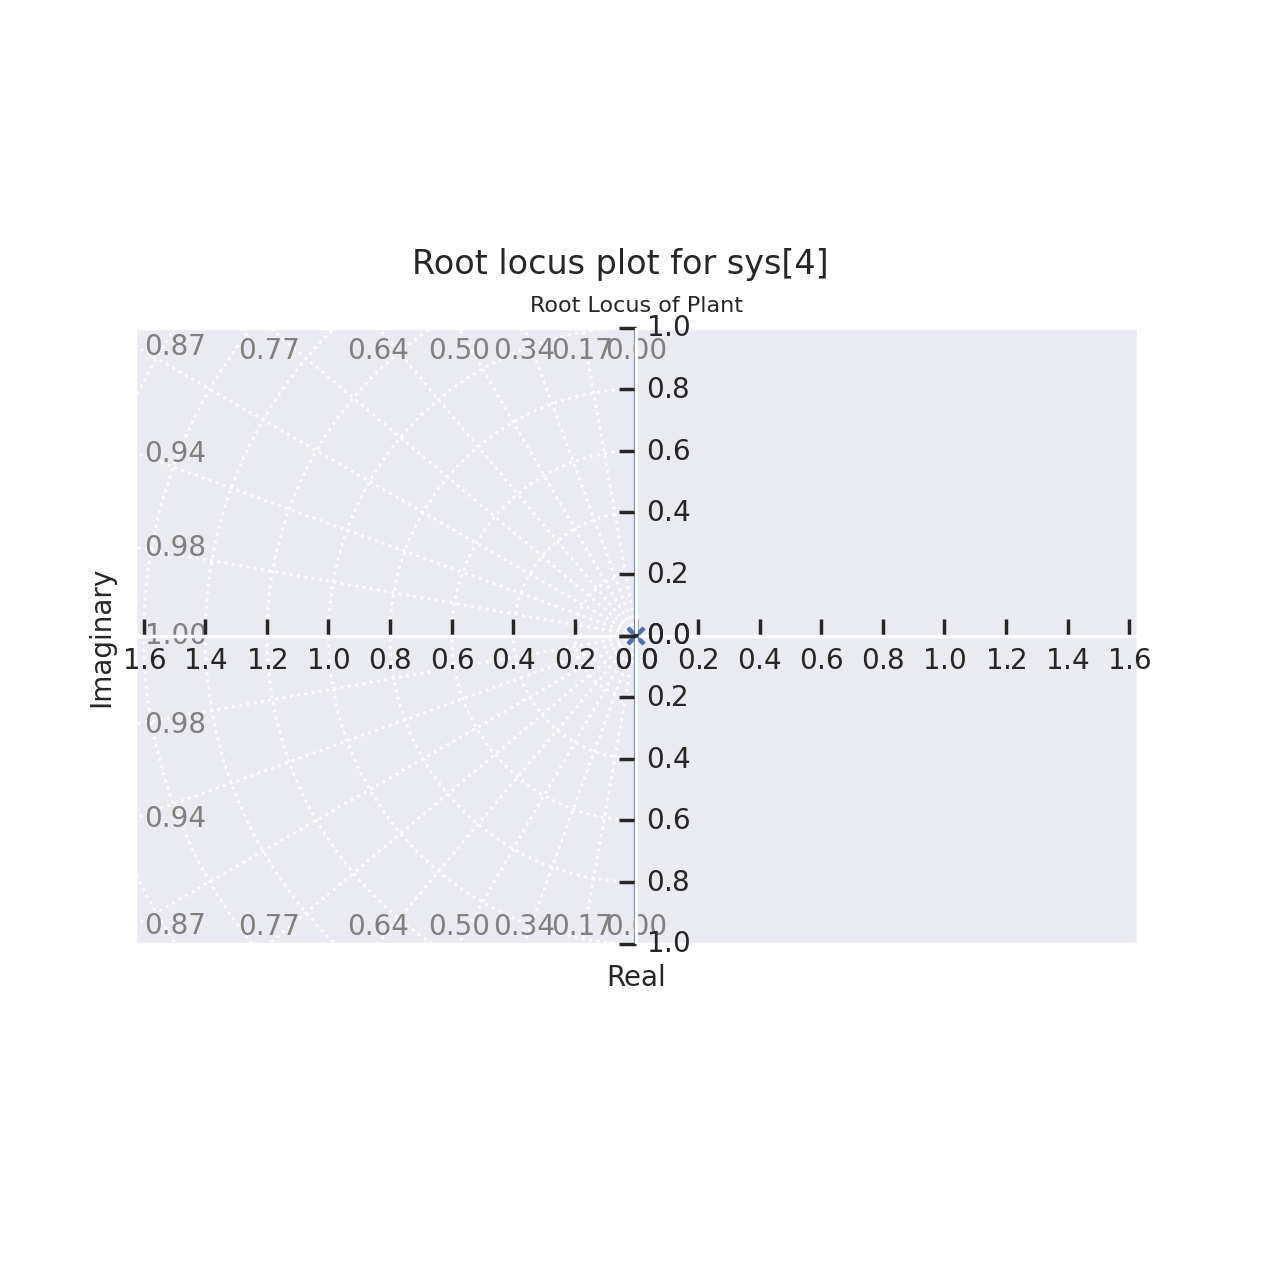

In [1]:
import control
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set(
    rc={
        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "figure.figsize": (4 * 1.618, 4),
        "figure.dpi": 200,
    }
)

m = 0.111
R = 0.015
g = -9.8
L = 1.0
d = 0.03
J = 9.99e-6
s = control.TransferFunction.s
P_ball = -m * g * d / L / (J / R**2 + m) / s**2

rlist, klist = control.rlocus(P_ball, plot=True, grid="on")
plt.title("Root Locus of Plant")
plt.show()

As you can see the system has two poles at the origin which go off to infinity along the imaginary axes.

The design criteria can also be plotted onto the root locus. The damping ratio and natural frequency were found using the following equation, which relates them to our percent overshoot (%OS) and settling time (Ts) requirements:

$$ \%OS = 100 e^{-\zeta \pi \sqrt{1-\zeta^2}} $$

$$ T_s = \frac{4}{\zeta \omega_n} $$

Note, that the equation with Ts is found by assuming the system has settled when the response remains within 2% of its final value. From these equations, the damping ratio and natural frequency were found to be 0.7 and 1.9 respectively.

The area between the two dotted diagonal lines represents locations where the percent overshoot is less than 5%. The area outside the curved line represents locations where the settling time is less than 3 seconds. Note that no region of the plot falls within the design criteria shown by these lines. To remedy this and bring the root locus into the left-hand plane for stability we will try adding a lead-compensator to the system.

## Lead controller

A first order lead compensator tends to shift the root locus into the left-hand plane. A lead compensator has the form given below:

$$ C(s) = K_c \frac{(s-z_0)}{(s-p_0)} $$

where, the magnitude of $z_0$ is less than the magnitude of $p_0$.

Now, let us add the controller to the plant and view the root locus. We will position the zero near the origin to cancel out one of the poles. The pole of our compensator will be placed to the left of the origin to pull the root locus further into the left-hand plane. Add the following lines of Python code to your code cell. Run your code cell and you should see the following:



/projects/UMich_Controls_Tutorials_Python/venv_UMich_Controls_Tutorials_Python/lib/python3.12/site-packages/control/rlocus.py:202: FutureWarning: root_locus() return value of roots, gains is deprecated; use root_locus_map()
  warnings.warn(
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


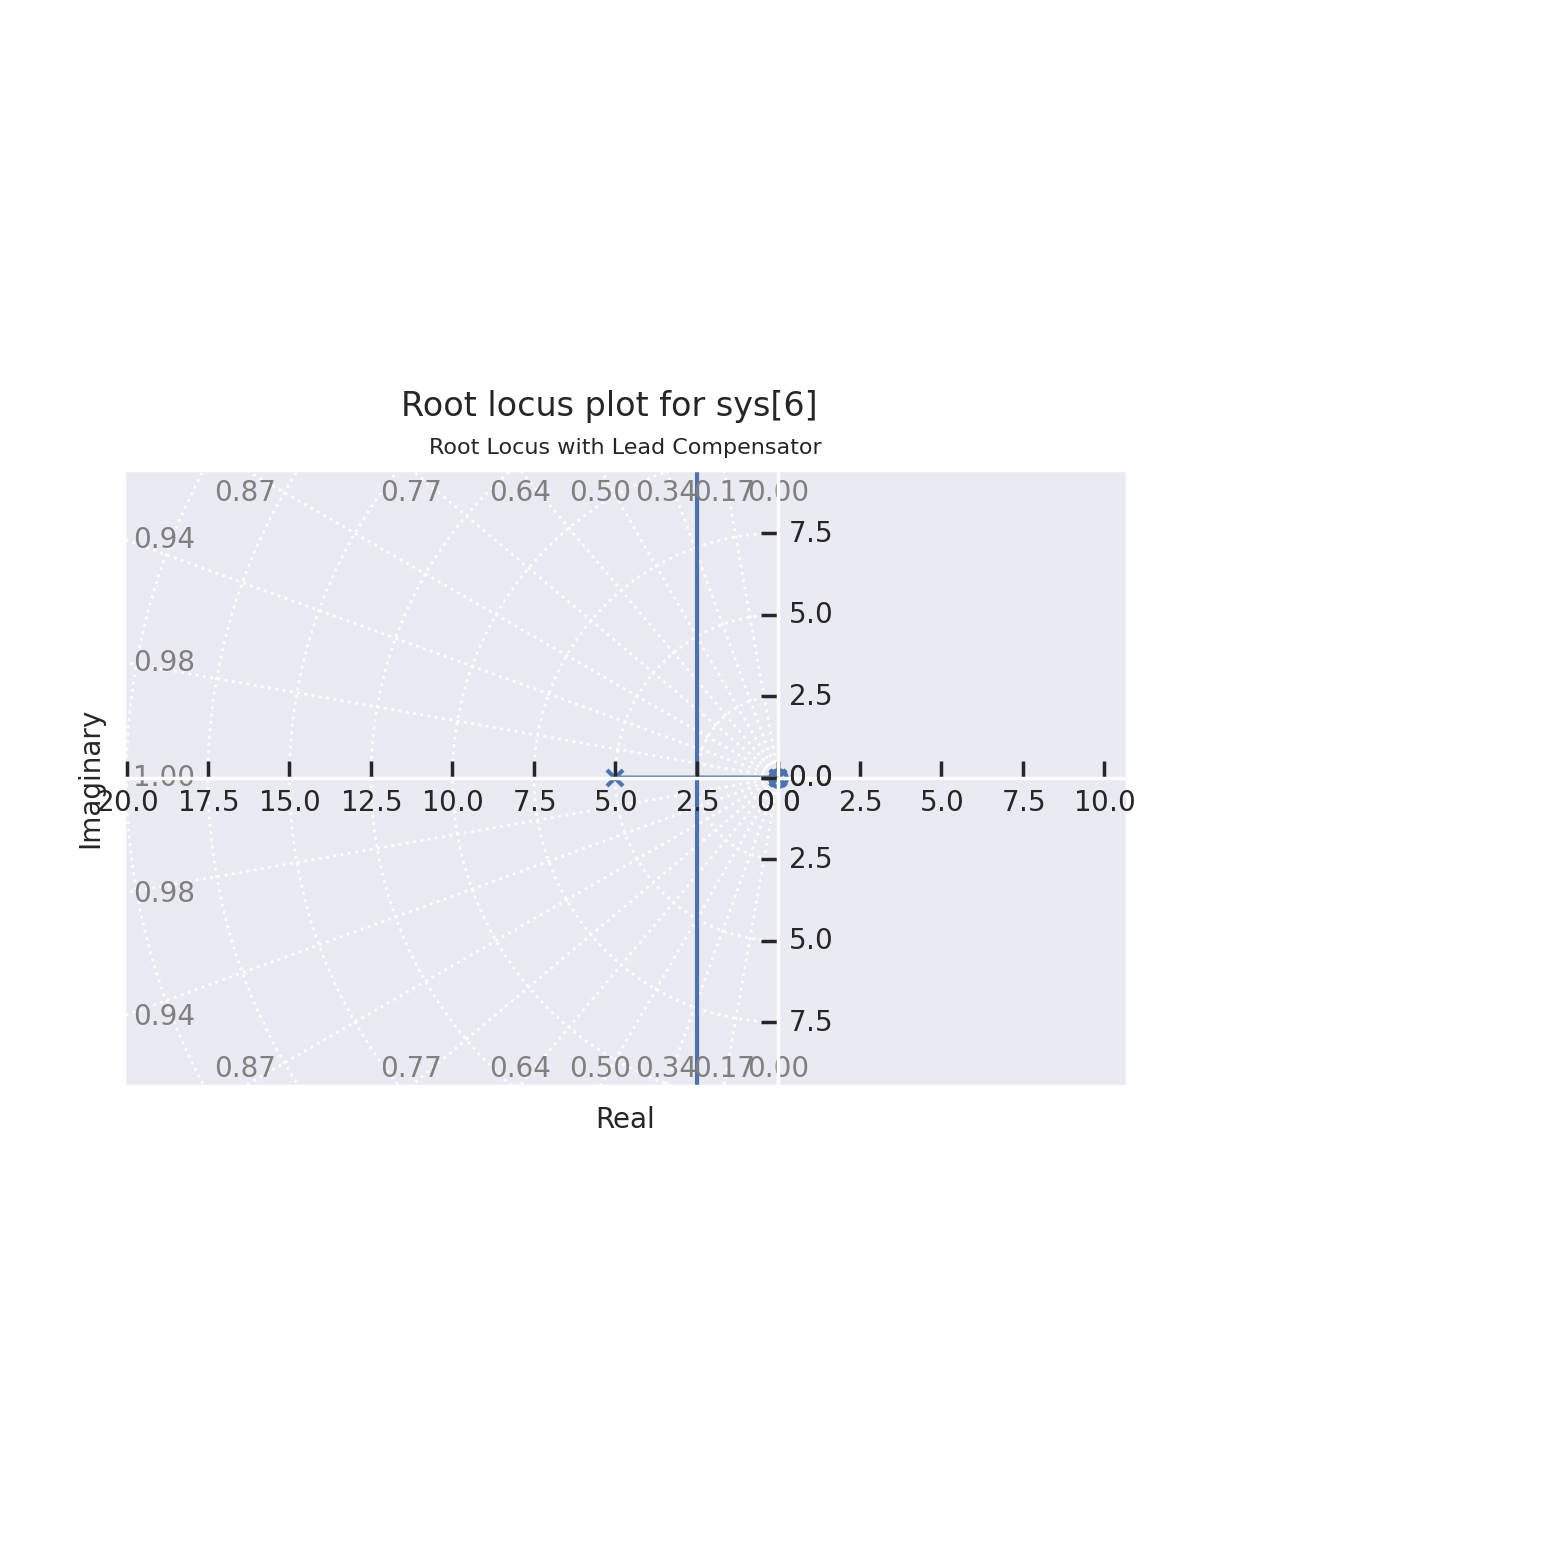

In [2]:
zo = 0.01
po = 5
C = control.TransferFunction([1, zo], [1, po])

rlist, klist = control.rlocus(C * P_ball, plot=True, grid="on")
plt.title("Root Locus with Lead Compensator")
plt.show()

Now, the branches of the root locus are within our design criteria.

## Selecting the gain

Now that we have moved the root locus into the left-hand plane, we may select a gain that will satisfy our design requirements. For this example, we'll use a gain $K_c$ of approximately 35. Then we can plot the closed-loop response to verify the design.

## Plotting the closed-loop response

This value of $K_c$ can be put into the system and the closed-loop response to a step input of 0.25 m can be obtained. Add the following lines to your code cell to perform this analysis. Run your code cell and the step response should look like the following.



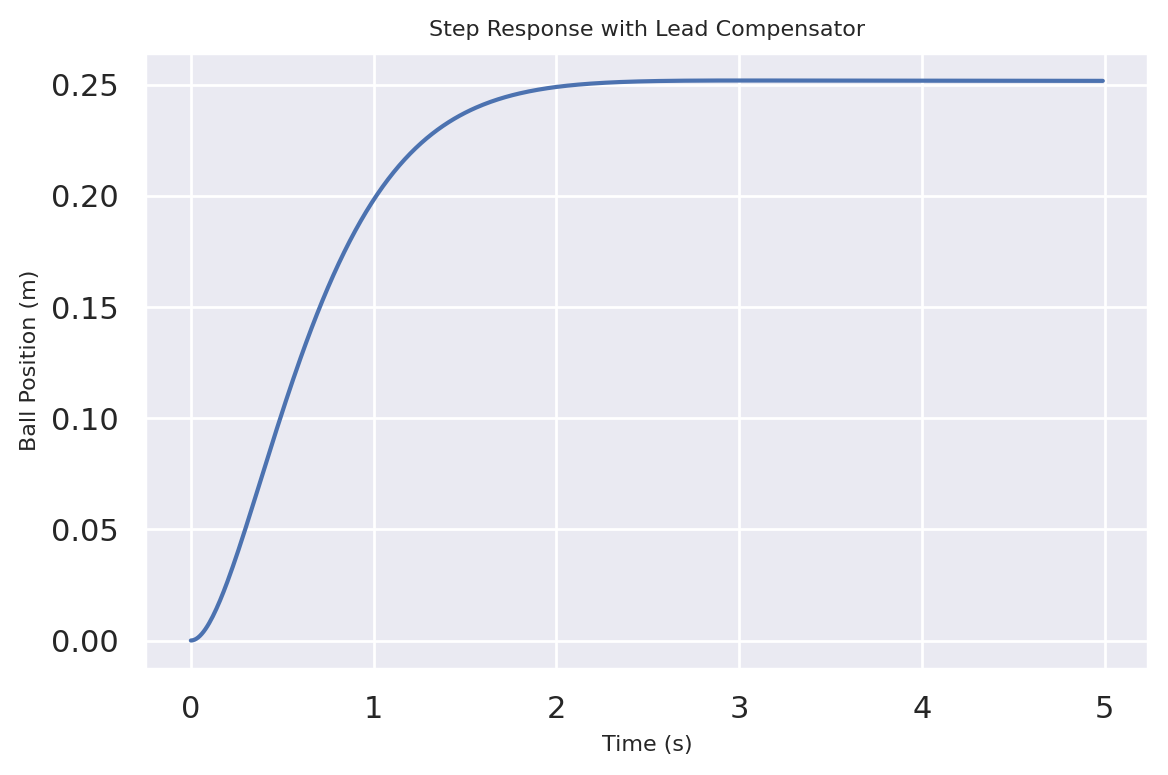

In [3]:
k = 35
sys_cl = control.feedback(k * C * P_ball, 1)
t = np.arange(0, 5, 0.01)
T, yout = control.step_response(0.25 * sys_cl, T=t)
plt.plot(T, yout)
plt.title("Step Response with Lead Compensator")
plt.xlabel("Time (s)")
plt.ylabel("Ball Position (m)")
plt.grid("on")
plt.show()

From this plot we see that when a 0.25 m step input is given to the system both the settling time and percent overshoot design criteria are met.

Note: A design problem does not necessarily have a unique answer. Using this method (or any other) may result in many different compensators. Try running your code cell several more times with different gain values and study the effect this has on the step response. For practice you may also want to go back to the original open-loop root locus and try to find other ways to add zeros and poles to get a better response.

